###############################################################################
#           Aydin Loid Karatas
#           ---
#           University of Southern California
#           Department of Quantitative and Computational Biology
#           Mooney Lab
#           ---
#           draw_3T.py
###############################################################################

In [49]:
import pickle
import demesdraw
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.patches import FancyArrowPatch

In [50]:
# plotting preparation
demo_pkl = "/scratch2/karatas/OOA_NAAdmixture_largeGrowth/pickled_demo_meta/HapMapII_GRCh38_1_chr1_all.demography.pkl"

with open(demo_pkl, "rb") as file:
    demo = pickle.load(file)

demo_graph = demo.to_demes()

# define population positions in drawn graph
AFR_loc = 0
EUR_loc = 1_050_000
ADX_loc = 510_000
positions = {
    "AFR": AFR_loc,

    "ADX_G1": ADX_loc,
    "ADX_G2": ADX_loc,
    "ADX_G3": ADX_loc,
    "ADX_G4": ADX_loc,

    "ADX": ADX_loc,

    "ADX_G5": ADX_loc,
    "ADX_G6": ADX_loc,
    "ADX_G7": ADX_loc,
    "ADX_G8": ADX_loc,
    "ADX_G9": ADX_loc,

    "EUR": EUR_loc,
}

# pop colors
colors = {
    "AFR": "#56B4E9",
    "EUR": "#fb8072",
}

# lavender/purple gradient from light -> dark
ADX_gradient = [
    "#E6D9FF",
    "#D6C2FF",
    "#C4A6FF",
    "#B38BFF",
    "#A06FFF",
    "#8D5AF5",
    "#7C49EC",
    "#703BE7",
    "#5E2FD1",
]
for i in range(1, 10):
    colors[f"ADX_G{i}"] = ADX_gradient[i - 1]
colors["ADX"] = "#4B1FA8"

# remove AFR <-> EUR migrataion lines for visualization
filtered_migrations = []
for mig in demo_graph.migrations:
    pair = {mig.source, mig.dest}
    if pair == {"AFR", "EUR"}:
        continue
    filtered_migrations.append(mig)
demo_graph.migrations = filtered_migrations

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

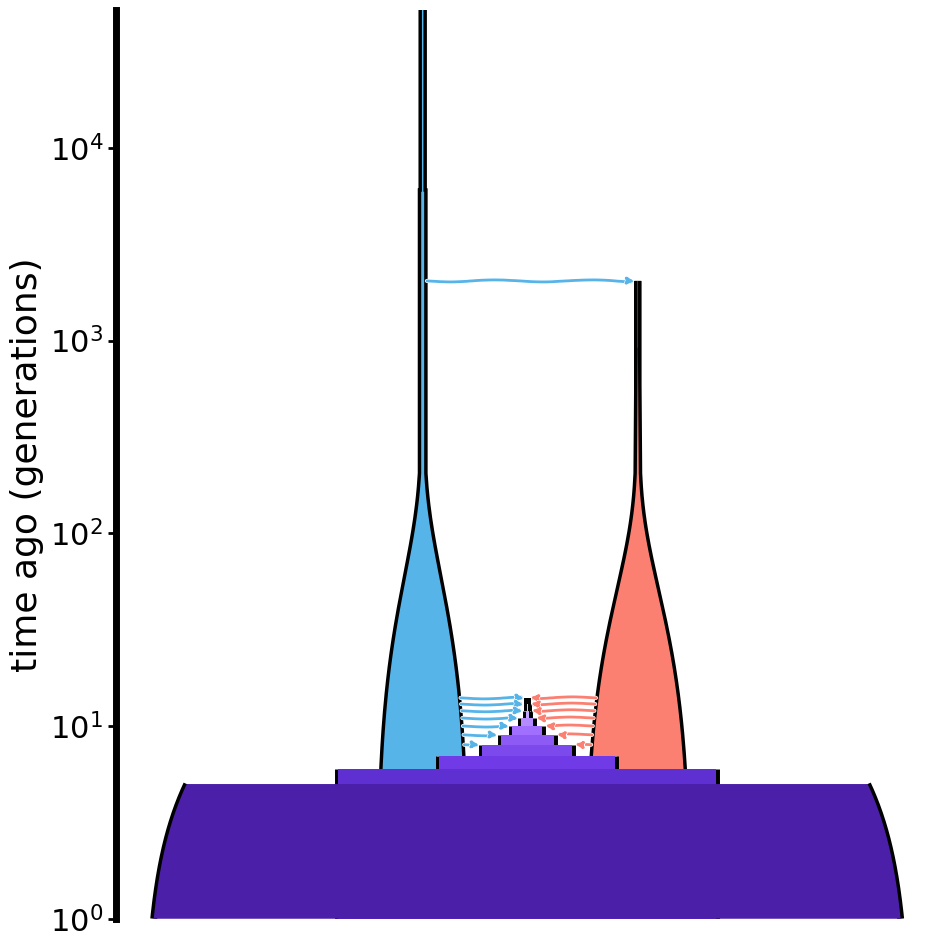

In [51]:
# plotting
plt.rcParams["svg.fonttype"] = "path"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.size"] = 24          # default font size for text elements
plt.rcParams["axes.labelsize"] = 26     # axis label sizes
plt.rcParams["xtick.labelsize"] = 22    # x-axis tick label sizes
plt.rcParams["ytick.labelsize"] = 22    # y-axis tick label sizes

fig, ax = plt.subplots(figsize=(10, 10))

demesdraw.tubes(
    demo_graph,
    ax=ax,
    positions=positions,
    colours=colors,
    log_time=True,
    labels=None
)

# add tube outlines
# outline only the population tubes
for patch in ax.patches:
    if isinstance(patch, FancyArrowPatch):
        # migration arrows: no outline
        patch.set_linewidth(2.0)
    else:
        # deme tubes: outlined
        patch.set_edgecolor("black")
        patch.set_linewidth(5.0)

# thicker axes
for spine in ax.spines.values():
    spine.set_linewidth(5.0)

ax.tick_params(width=2, length=6)

# ax.text(AFR_loc, 0.6, "AFR", ha="center", fontsize="large")
# ax.text(ADX_loc, 0.6, "ADX", ha="center", fontsize="large")
# ax.text(EUR_loc, 0.6, "EUR", ha="center", fontsize="large")

for artist in ax.get_children():
    if hasattr(artist, "set_alpha"):
        artist.set_alpha(1.0)

plt.tight_layout()

fig.savefig(
    "/project2/jazlynmo_738/karatas/"
    "OOA_NAAdmixture_data/demography_plot.svg",
    format="svg",
    bbox_inches="tight",
    transparent=True,
)

plt.show()